# Machine Learning - Clustering e Interpretación (Diabetes)

[![francomansilla.com](https://img.shields.io/badge/francomansilla.com-555555?style=flat&logo=globe&logoColor=white)](https://www.francomansilla.com)

Este notebook desarrolla un flujo de aprendizaje no supervisado y explicabilidad sobre el dataset de diabetes. Primero se limpian variables clínicas, luego se construyen clusters con PCA + K-Means y, finalmente, se interpretan con modelos Random Forest one-vs-rest para identificar qué variables explican cada grupo.

<br>

**Librerías**

[![Pandas](https://img.shields.io/badge/Pandas-150458?style=flat&logo=pandas&logoColor=white)](https://pandas.pydata.org/docs/)
[![NumPy](https://img.shields.io/badge/NumPy-013243?style=flat&logo=numpy&logoColor=white)](https://numpy.org/doc/)
[![Matplotlib](https://img.shields.io/badge/Matplotlib-11557c?style=flat&logo=python&logoColor=white)](https://matplotlib.org/stable/index.html)
[![scikit-learn](https://img.shields.io/badge/scikit--learn-F7931E?style=flat&logo=scikit-learn&logoColor=white)](https://scikit-learn.org/stable/)

**Modelos y métodos usados**

[![KMeans](https://img.shields.io/badge/KMeans-006400?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
[![PCA](https://img.shields.io/badge/PCA-8B0000?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
[![RandomForestClassifier](https://img.shields.io/badge/RandomForestClassifier-228B22?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
[![StandardScaler](https://img.shields.io/badge/StandardScaler-2E8B57?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
[![train_test_split](https://img.shields.io/badge/train__test__split-6A5ACD?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

**Métricas**

[![Silhouette](https://img.shields.io/badge/Silhouette-1E90FF?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)
[![Calinski-Harabasz](https://img.shields.io/badge/Calinski--Harabasz-FF8C00?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html)
[![Davies-Bouldin](https://img.shields.io/badge/Davies--Bouldin-20B2AA?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.davies_bouldin_score.html)
[![Accuracy](https://img.shields.io/badge/Accuracy-DC143C?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)
[![F1](https://img.shields.io/badge/F1_Score-B8860B?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)
[![ROC-AUC](https://img.shields.io/badge/ROC--AUC-228B22?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html)

---

## 1) Importación de librerías y carga de datos

Se importan las librerías del análisis y se carga el dataset de diabetes desde GitHub para construir la base de trabajo inicial.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    accuracy_score, f1_score, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Carga de datos
df = pd.read_csv(
    'https://raw.githubusercontent.com/fmansillaib/umayor_class/main/datasets/datos_transversales_paneles/diabetes/datos.csv'
)

## 2) Depuración de datos y construcción de la base PCA

Se corrigen ceros no plausibles en variables clínicas y luego se reduce dimensionalidad con PCA hasta cubrir el 90% de la varianza acumulada.

In [2]:
# 2) Depuracion simple para clustering
cols_cero_sospechoso = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_model = df.copy()
for col in cols_cero_sospechoso:
    mediana_col = df_model.loc[df_model[col] != 0, col].median()
    df_model.loc[df_model[col] == 0, col] = mediana_col

# 3) Base PCA final (90% varianza acumulada)
target = 'Outcome'
X = df_model.drop(columns=[target], errors='ignore').copy()
X_scaled = StandardScaler().fit_transform(X)

pca_full = PCA().fit(X_scaled)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_90 = int(np.argmax(var_acum >= 0.90) + 1)

X_pca = PCA(n_components=n_comp_90, random_state=42).fit_transform(X_scaled)


## 3) Clustering final con K-Means y métricas

Se ajusta K-Means con 4 clusters sobre la base PCA y se reportan métricas internas de calidad (Silhouette, Calinski-Harabasz y Davies-Bouldin), además de la distribución de Outcome por cluster.

In [3]:
# 4) K-Means final
k = 4
kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
labels = kmeans.fit_predict(X_pca)

# 5) Metricas finales
sil = silhouette_score(X_pca, labels)
ch = calinski_harabasz_score(X_pca, labels)
db = davies_bouldin_score(X_pca, labels)

df_eval = pd.DataFrame({'Cluster': labels, 'Outcome': df_model[target].values})
outcome_pct = pd.crosstab(df_eval['Cluster'], df_eval['Outcome'], normalize='index') * 100

print('Metricas finales (PCA + KMeans k=4)')
print(f'Silhouette: {sil:.4f}')
print(f'Calinski-Harabasz: {ch:.4f}')
print(f'Davies-Bouldin: {db:.4f}')
print(f'Componentes PCA (90% varianza): {n_comp_90}')
print('\nDistribucion Outcome (%) por cluster:')
print(outcome_pct.round(2))

Metricas finales (PCA + KMeans k=4)
Silhouette: 0.0911
Calinski-Harabasz: 70.2921
Davies-Bouldin: 2.3414
Componentes PCA (90% varianza): 8

Distribucion Outcome (%) por cluster:
Outcome      0      1
Cluster              
0        40.62  59.38
1        76.70  23.30
2        70.05  29.95
3        72.83  27.17


## 4) Preparación para interpretación con Random Forest

Se define la base de entrada para clasificación one-vs-rest, se inicializa el contenedor de resultados y se crea la función auxiliar para entrenar cada modelo y extraer importancias.

In [4]:
# Preparacion para Random Forest: variables, contenedor de resultados y funcion helper
X_rf = df_model.drop(columns=['Outcome'], errors='ignore').copy()
resultados_rf = {}

def rf_cluster_one_vs_rest(cluster_objetivo, X, y_clusters):
    y_bin = (y_clusters == cluster_objetivo).astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_bin, test_size=0.30, random_state=42, stratify=y_bin
    )
    rf = RandomForestClassifier(
        n_estimators=600, random_state=42, class_weight='balanced', n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)[:, 1]
    metricas = {
        'cluster_objetivo': cluster_objetivo,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'positivos_train': int(y_train.sum()),
        'positivos_test': int(y_test.sum())
    }
    importancia = pd.DataFrame({
        'variable': X.columns,
        'importancia': rf.feature_importances_
    }).sort_values('importancia', ascending=False).reset_index(drop=True)
    return metricas, importancia

print('Preparacion RF lista: X_rf, resultados_rf y rf_cluster_one_vs_rest definidos.')

Preparacion RF lista: X_rf, resultados_rf y rf_cluster_one_vs_rest definidos.


### Modelo 1: Random Forest para Cluster 0 vs resto

Este modelo clasifica `Cluster 0 = 1` y `Clusters 1,2,3 = 0` usando todas las variables clínicas. Se reportan métricas y la importancia de cada variable.

In [5]:
metricas_c0, imp_c0 = rf_cluster_one_vs_rest(0, X_rf, labels)
resultados_rf[0] = {'metricas': metricas_c0, 'importancia': imp_c0}

print('Random Forest: cluster 0 = 1, resto = 0')
print(f"Accuracy: {metricas_c0['accuracy']:.4f}")
print(f"F1:       {metricas_c0['f1']:.4f}")
print(f"ROC-AUC:  {metricas_c0['roc_auc']:.4f}")
print(f"Positivos train/test: {metricas_c0['positivos_train']}/{metricas_c0['positivos_test']}")
print('\nImportancia de variables - Cluster 0:')
display(imp_c0)

Random Forest: cluster 0 = 1, resto = 0
Accuracy: 0.8874
F1:       0.7347
ROC-AUC:  0.9682
Positivos train/test: 134/58

Importancia de variables - Cluster 0:


,variable,importancia
0,Glucose,0.325249
1,BMI,0.160824
2,Insulin,0.159271
3,BloodPressure,0.109185
4,Age,0.078251
5,DiabetesPedigreeFunction,0.063746
6,SkinThickness,0.060228
7,Pregnancies,0.043246


### Modelo 2: Random Forest para Cluster 1 vs resto

Este modelo clasifica `Cluster 1 = 1` y `Clusters 0,2,3 = 0`, permitiendo identificar qué variables separan mejor este grupo del resto.

In [6]:
metricas_c1, imp_c1 = rf_cluster_one_vs_rest(1, X_rf, labels)
resultados_rf[1] = {'metricas': metricas_c1, 'importancia': imp_c1}

print('Random Forest: cluster 1 = 1, resto = 0')
print(f"Accuracy: {metricas_c1['accuracy']:.4f}")
print(f"F1:       {metricas_c1['f1']:.4f}")
print(f"ROC-AUC:  {metricas_c1['roc_auc']:.4f}")
print(f"Positivos train/test: {metricas_c1['positivos_train']}/{metricas_c1['positivos_test']}")
print('\nImportancia de variables - Cluster 1:')
display(imp_c1)

Random Forest: cluster 1 = 1, resto = 0
Accuracy: 0.9307
F1:       0.8596
ROC-AUC:  0.9920
Positivos train/test: 144/62

Importancia de variables - Cluster 1:


,variable,importancia
0,Age,0.463348
1,Glucose,0.155391
2,Insulin,0.113697
3,BMI,0.072782
4,SkinThickness,0.051859
5,DiabetesPedigreeFunction,0.050538
6,BloodPressure,0.050511
7,Pregnancies,0.041876


### Modelo 3: Random Forest para Cluster 2 vs resto

Este modelo clasifica `Cluster 2 = 1` y `Clusters 0,1,3 = 0`, para evaluar las variables más discriminantes de este perfil.

In [7]:
metricas_c2, imp_c2 = rf_cluster_one_vs_rest(2, X_rf, labels)
resultados_rf[2] = {'metricas': metricas_c2, 'importancia': imp_c2}

print('Random Forest: cluster 2 = 1, resto = 0')
print(f"Accuracy: {metricas_c2['accuracy']:.4f}")
print(f"F1:       {metricas_c2['f1']:.4f}")
print(f"ROC-AUC:  {metricas_c2['roc_auc']:.4f}")
print(f"Positivos train/test: {metricas_c2['positivos_train']}/{metricas_c2['positivos_test']}")
print('\nImportancia de variables - Cluster 2:')
display(imp_c2)

Random Forest: cluster 2 = 1, resto = 0
Accuracy: 0.9351
F1:       0.8649
ROC-AUC:  0.9865
Positivos train/test: 138/59

Importancia de variables - Cluster 2:


,variable,importancia
0,Pregnancies,0.300436
1,Age,0.295766
2,BMI,0.119693
3,Glucose,0.070012
4,SkinThickness,0.057227
5,Insulin,0.056657
6,BloodPressure,0.055424
7,DiabetesPedigreeFunction,0.044784


### Modelo 4: Random Forest para Cluster 3 vs resto

Este modelo clasifica `Cluster 3 = 1` y `Clusters 0,1,2 = 0`, completando el análisis one-vs-rest para los cuatro grupos.

In [8]:
metricas_c3, imp_c3 = rf_cluster_one_vs_rest(3, X_rf, labels)
resultados_rf[3] = {'metricas': metricas_c3, 'importancia': imp_c3}

print('Random Forest: cluster 3 = 1, resto = 0')
print(f"Accuracy: {metricas_c3['accuracy']:.4f}")
print(f"F1:       {metricas_c3['f1']:.4f}")
print(f"ROC-AUC:  {metricas_c3['roc_auc']:.4f}")
print(f"Positivos train/test: {metricas_c3['positivos_train']}/{metricas_c3['positivos_test']}")
print('\nImportancia de variables - Cluster 3:')
display(imp_c3)

Random Forest: cluster 3 = 1, resto = 0
Accuracy: 0.9004
F1:       0.7416
ROC-AUC:  0.9635
Positivos train/test: 121/52

Importancia de variables - Cluster 3:


,variable,importancia
0,Pregnancies,0.388744
1,Age,0.197313
2,DiabetesPedigreeFunction,0.107701
3,Glucose,0.073658
4,Insulin,0.072695
5,BloodPressure,0.061163
6,SkinThickness,0.049984
7,BMI,0.048742


### Comparación final: importancias por modelo en subplots

Cada subplot muestra las importancias de las variables para un modelo RF one-vs-rest. Las variables están ordenadas de mayor a menor importancia dentro de cada modelo.

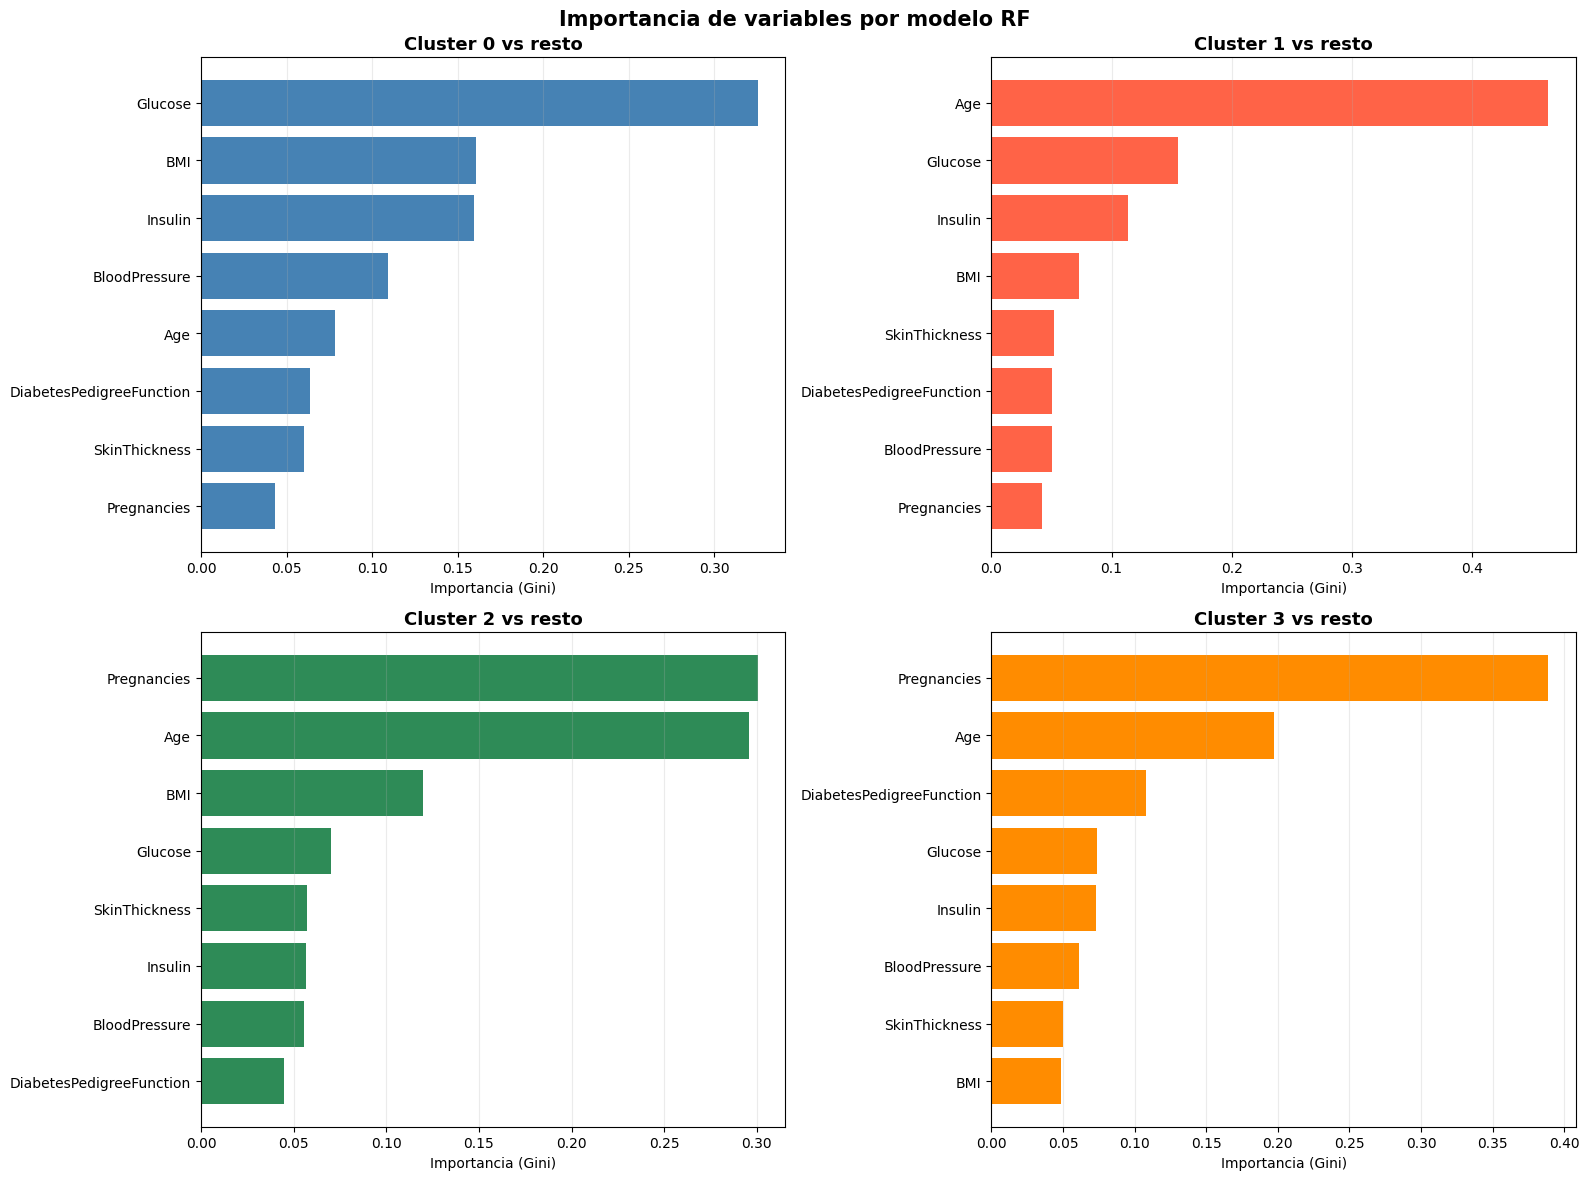

In [9]:
if not all(cl in resultados_rf for cl in [0, 1, 2, 3]):
    raise ValueError('Ejecuta primero los 4 modelos RF.')

colores_sub = {0: 'steelblue', 1: 'tomato', 2: 'seagreen', 3: 'darkorange'}

fig_sub, axes_sub = plt.subplots(2, 2, figsize=(16, 12))
axes_sub = axes_sub.flatten()

for i, cl in enumerate([0, 1, 2, 3]):
    imp_sub = resultados_rf[cl]['importancia'].sort_values('importancia', ascending=True)
    axes_sub[i].barh(imp_sub['variable'], imp_sub['importancia'], color=colores_sub[cl])
    axes_sub[i].set_title(f'Cluster {cl} vs resto', fontsize=13, fontweight='bold')
    axes_sub[i].set_xlabel('Importancia (Gini)')
    axes_sub[i].grid(axis='x', alpha=0.25)

fig_sub.suptitle('Importancia de variables por modelo RF', fontsize=15, fontweight='bold')
fig_sub.tight_layout()
plt.show()

### Scatter: top 2 variables por cluster vs Outcome

Para cada cluster se toman las dos variables más importantes del modelo RF y se grafica un scatter coloreado por `Outcome` (0 = sin diabetes, 1 = con diabetes). Permite ver visualmente si esas variables separan bien los casos clínicos dentro de cada grupo.

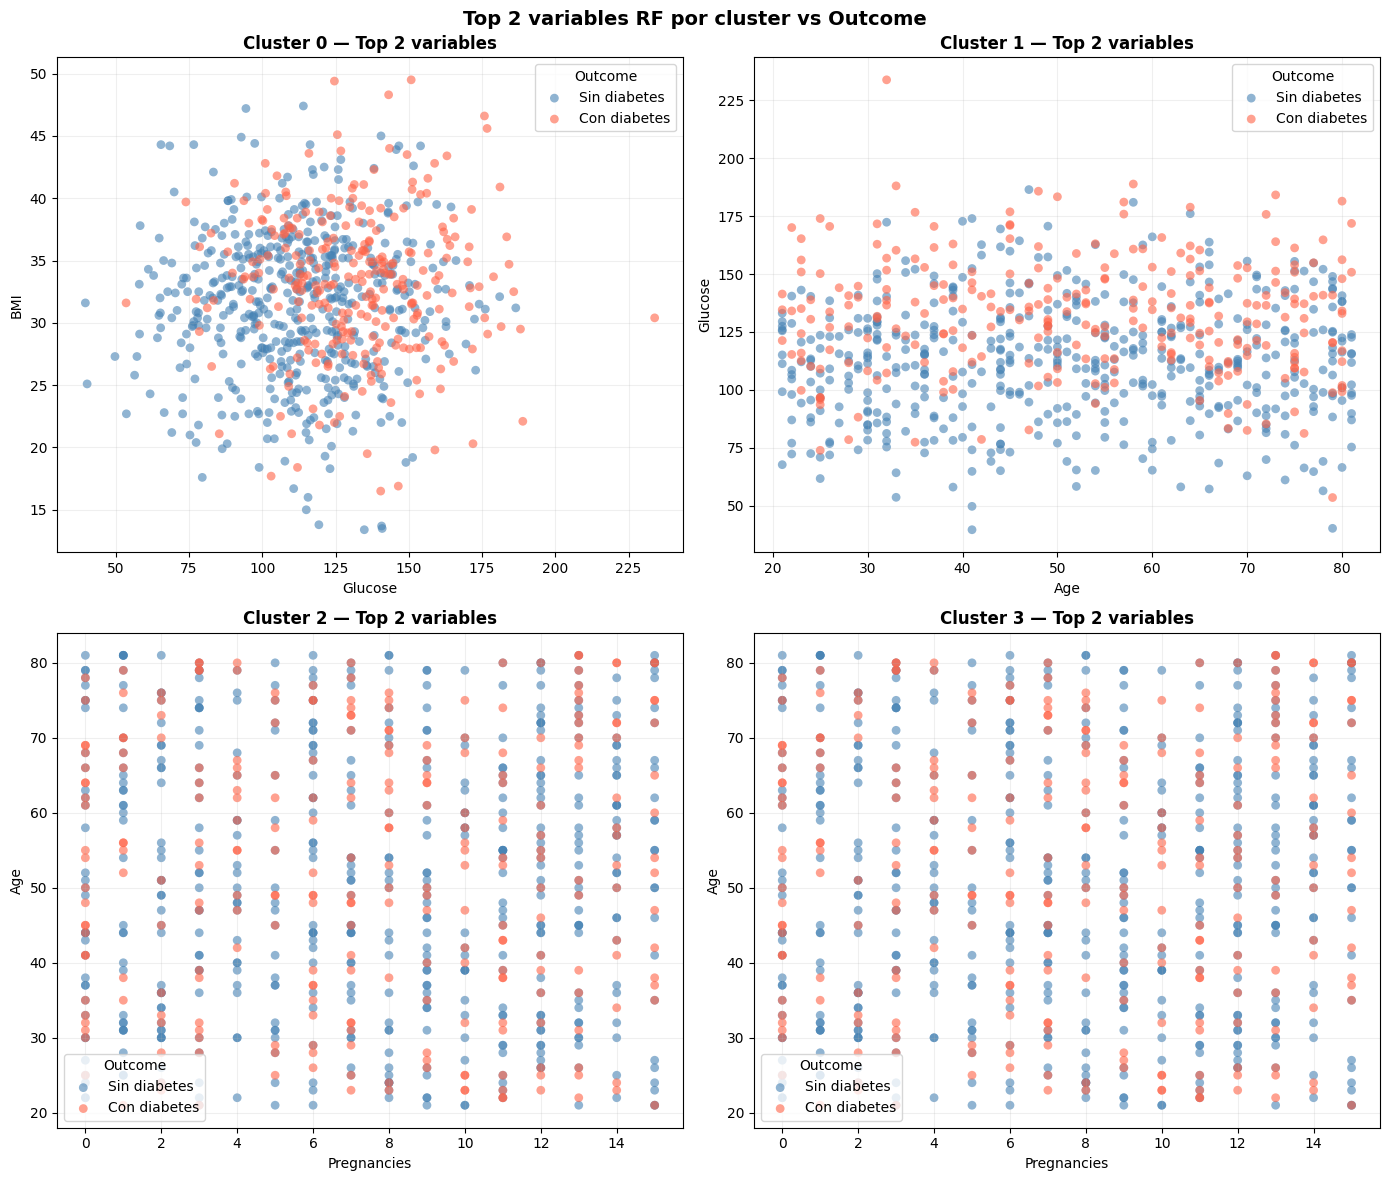

In [10]:
# Top 2 variables por cluster desde las importancias RF
top2 = {
    cl: resultados_rf[cl]['importancia']['variable'].iloc[:2].tolist()
    for cl in [0, 1, 2, 3]
}

outcome = df_model['Outcome'].values
colores_outcome = {0: 'steelblue', 1: 'tomato'}
labels_outcome = {0: 'Sin diabetes', 1: 'Con diabetes'}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, cl in enumerate([0, 1, 2, 3]):
    v1, v2 = top2[cl]
    ax = axes[i]

    for oc in [0, 1]:
        mask = outcome == oc
        ax.scatter(
            df_model.loc[mask, v1],
            df_model.loc[mask, v2],
            c=colores_outcome[oc],
            label=labels_outcome[oc],
            alpha=0.6,
            s=40,
            edgecolors='none'
        )

    ax.set_title(f'Cluster {cl} — Top 2 variables', fontsize=12, fontweight='bold')
    ax.set_xlabel(v1)
    ax.set_ylabel(v2)
    ax.legend(title='Outcome')
    ax.grid(alpha=0.2)

plt.suptitle('Top 2 variables RF por cluster vs Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretación de clusters: perfil de pacientes

A partir de las tres variables más importantes de cada modelo Random Forest, se puede caracterizar el tipo de paciente que cae en cada cluster:

---

### Cluster 0 — Perfil metabólico severo
**Variables dominantes:** `Glucose`, `BMI`, `Insulin`

Pacientes con glucosa elevada, sobrepeso u obesidad e insulina alta. Son el grupo con **mayor proporción de diabetes (~59%)**. El perfil sugiere resistencia a la insulina o diabetes tipo 2 establecida. Son los pacientes clínicamente más comprometidos.

---

### Cluster 1 — Adulto mayor con deterioro metabólico gradual
**Variables dominantes:** `Age`, `Glucose`, `Insulin`

La edad domina fuertemente (importancia ≈0.46). Son pacientes **mayores** con glucosa e insulina moderadamente alteradas (~23% con diabetes). El deterioro metabólico parece ligado al envejecimiento más que a factores de estilo de vida agudos.

---

### Cluster 2 — Perfil reproductivo con riesgo acumulado
**Variables dominantes:** `Pregnancies`, `Age`, `BMI`

Mujeres con **múltiples embarazos**, edad media-alta y mayor IMC (~30% con diabetes). El historial reproductivo es el factor más relevante. Perfil compatible con antecedentes de diabetes gestacional o riesgo acumulado por paridad.

---

### Cluster 3 — Predisposición genético-reproductiva
**Variables dominantes:** `Pregnancies`, `Age`, `DiabetesPedigreeFunction`

Mujeres con múltiples embarazos, edad media y **antecedentes familiares de diabetes** (`DiabetesPedigreeFunction`). El riesgo es más genético-hereditario que metabólico directo (~27% con diabetes). Perfil de predisposición familiar con historial reproductivo.

---

### Resumen comparativo

| Cluster | Perfil | % Diabetes |
|---------|--------|------------|
| 0 | Metabólico severo (glucosa + obesidad + insulina) | ~59% |
| 1 | Adulto mayor con deterioro metabólico gradual | ~23% |
| 2 | Reproductivo (paridad + edad + obesidad) | ~30% |
| 3 | Genético-reproductivo (herencia + paridad) | ~27% |